In [3]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from skimage import feature
import pickle
import os

In [51]:
LIMIT = 1300
IMG_SIZE = (227, 227)
LABELS = np.array(['bacterial_leaf_blight', 'Hispa', 'brown_spot', 'normal'])

In [52]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
        print(f"Loaded {len(data)} images from {folder_name}")
    
    return np.array(data), np.array(labels)


In [53]:
test_dataset, labels = load_images_from_directory('datasets/Rice Diseases Image Dataset/validation', LIMIT)

123 images in bacterial_leaf_blight
Loaded 123 images from bacterial_leaf_blight
123 images in Hispa
Loaded 246 images from Hispa
123 images in brown_spot
Loaded 369 images from brown_spot
123 images in normal
Loaded 492 images from normal


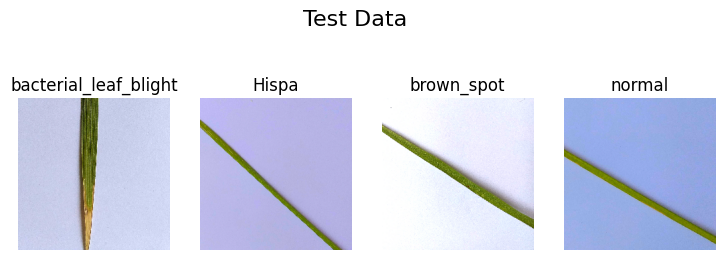

In [54]:
fig = plt.figure(figsize=(9, 6))

fig.suptitle('Test Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(2, len(LABELS), j+1)
    index = np.where(labels == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(test_dataset[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])

In [55]:
# def segment_image(image, label):
def segment_image(image):
    
    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # mask = np.zeros(image.shape[:2], np.uint8)
    # bgModel = np.zeros((1, 65), np.float64)
    # fgModel = np.zeros((1, 65), np.float64)

    # # Rectangle awal perkiraan daun
    # rect = (1, 1, 225, 225)
    # cv2.grabCut(image, mask, rect, bgModel, fgModel, 8, cv2.GC_INIT_WITH_RECT)

    # mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask2*255, cv2.COLOR_BGR2RGB))
    
    lower_yellow = np.array([ 15, 0, 56])  # Adjust as needed
    upper_yellow = np.array([32, 255, 255])  # Adjust as
    
    lower_chocolate = np.array([0, 10, 0])
    upper_chocolate = np.array([15, 255, 255])
    
    yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
    dark_chocolate_mask = cv2.inRange(hsv_img, lower_chocolate, upper_chocolate)
    
    mask3 = cv2.bitwise_or(yellow_mask, dark_chocolate_mask)
    # mask3 = cv2.bitwise_and(mask3, mask3, mask=mask2)
    
    # print(mask3.max(), image.shape)
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask3, cv2.COLOR_BGR2RGB))
    
    # mask = cv2.erode(mask, None, iterations=2)
    # mask = cv2.dilate(mask, None, iterations=2)
    # mask = cv2.bitwise_not(mask)
    result = cv2.bitwise_and(image, image, mask=mask3)
    
    return result
    # return mask

In [56]:
def calculate_texture_features_n_hog(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = feature.graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')
    energy = feature.graycoprops(glcm, 'energy')
    homogeneity = feature.graycoprops(glcm, 'homogeneity')
    correlation = feature.graycoprops(glcm, 'correlation')
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')
    
    # lbp = feature.local_binary_pattern(gray, P=8, R=1, method='uniform')
    hog = feature.hog(gray, pixels_per_cell=(30, 30), cells_per_block=(1, 1), visualize=False, feature_vector=True)
    # return hog
    # return np.concatenate((lbp.flatten(), hog))
    return np.concatenate((hog,contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))
    # return np.concatenate((contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))
    # return np.concatenate((hog,glcm.flatten()))

In [57]:
def calculate_histogram(image, channels, mask=None, histSize=[256], ranges=[0, 256]):
    result = []
    for i in range(len(channels)):
        hist = cv2.calcHist([image], [i], mask, histSize, ranges)
        cv2.normalize(hist, hist)
        hist.flatten()
        result.append(hist)
    return np.array(result).flatten()

In [ ]:
def extract_features(images):
    features = []
    for img in images:
        # normalized = normalize_image(img)
        # segmented = segment_image(normalized)
        segmented = segment_image(img)
        # normalized_255 = np.clip(normalized * 255, 0, 255).astype(np.uint8)
        # fig = plt.figure(figsize=(9, 6))

        # plt.imshow(cv2.cvtColor(normalized_255, cv2.COLOR_BGR2RGB))
        # plt.axis('off') 
        # plt.title(LABELS[j])
        # color_hist_hsv = calculate_histogram(cv2.cvtColor(normalized, cv2.COLOR_BGR2HSV), channels=[0, 1, 2])
        color_hist_hsv = calculate_histogram(cv2.cvtColor(segmented, cv2.COLOR_BGR2HSV), channels=[0, 1, 2])
        # color_hist_rgb = calculate_histogram(segmented, channels=[0, 1, 2])
        # color_moments = calculate_color_moments(segmented)
        # hu_moments = cv2.HuMoments(cv2.moments(cv2.cvtColor(segmented, cv2.COLOR_BGR2GRAY))).flatten()
        texture_features_n_hog = calculate_texture_features_n_hog(segmented)
        # feature_vector = np.concatenate((color_hist, color_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist, color_moments, hu_moments))
        # feature_vector = np.concatenate((color_hist_hsv, color_hist_rgb, hu_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist_hsv, hu_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist_hsv, hu_moments))
        # feature_vector = np.concatenate((hu_moments, texture_features_n_hog))
        feature_vector = np.concatenate((color_hist_hsv, texture_features_n_hog)) # hog 76% accuracy | glcm 72% accuracy | hog & glcm 78% accuracy
        features.append(feature_vector)
        # features.append(color_hist_hsv) #72%
        # features.append(hu_moments) #36%
        # features.append(texture_features_n_hog) #59% hog | 43% texture
    return np.array(features)

In [59]:
feature_img1 = extract_features([test_dataset[0]])
print(feature_img1.shape)

(1, 1214)


In [60]:
test_dataset_features = extract_features(test_dataset)

In [61]:
# Load the model from disk
with open('Results/250704 1911 Mixed On Field/svm.pkl', 'rb') as file:
  loaded_classifier = pickle.load(file) 

# Use the loaded model to make predictions on new data
with open('Results/250704 1911 Mixed On Field/scaler.pkl', 'rb') as file:
  loaded_scaler = pickle.load(file) 

x_test_normal = loaded_scaler.transform(test_dataset_features)
predictions = loaded_classifier.predict(x_test_normal)

In [62]:
# Evaluate the model
accuracy = accuracy_score(labels, predictions)
print(f"Accuracy: {accuracy * 100:.4f}%")
precision, recall, fscore, average = precision_recall_fscore_support(labels, predictions, average='weighted')
print(f"Precission: {precision * 100:.4f}%")
print(f"Recall: {recall * 100:.4f}%")
print(f"F1: {fscore * 100:.4f}%")

Accuracy: 25.8130%
Precission: 20.2600%
Recall: 25.8130%
F1: 13.0872%


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [63]:
print(predictions[50:150])
print(labels[50:150])

print(predictions.shape, labels.shape)

['bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'bacterial_leaf_blight'
 'bacterial_leaf_blight' 'bacterial_leaf_blight' 'b

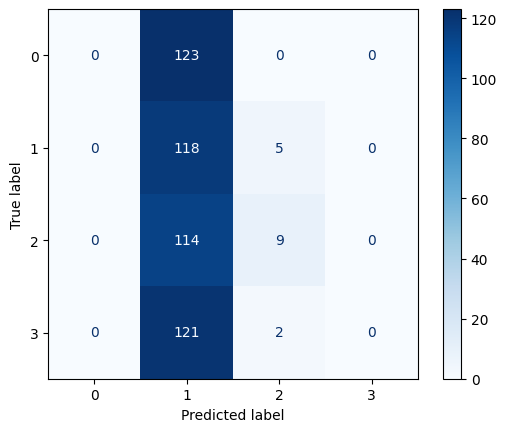

In [64]:
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()